In [5]:
!pip install botorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 41.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.8/287.8 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.3/176.3 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 5.0 MB/s eta 0:00:00


In [1]:
%cd s4bo

/content/s4bo


In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [3]:
def plot_true_function(test_function, n_points=101, fixed_dims_value=0.3):
    dim = test_function.dim
    bounds_tensor = test_function.bounds.detach().cpu()

    if bounds_tensor.shape[0] == 2:
        bounds_tensor = bounds_tensor #(2,d)
    elif bounds_tensor.shape[1] == 2:
        bounds_tensor = bounds_tensor.T #(d,2) -> (2,d)
    bounds_np = bounds_tensor.numpy()

    x1 = np.linspace(bounds_np[0, 0], bounds_np[1, 0], n_points)
    x2 = np.linspace(bounds_np[0, 1], bounds_np[1, 1], n_points)
    X1, X2 = np.meshgrid(x1, x2)

    if dim == 2:
        pts = np.column_stack([X1.ravel(), X2.ravel()])
        pts_t = torch.tensor(pts, dtype=torch.float32)
    else:
        # for all dimensions we set constant number fixed_dims_value - plot is different for each of them
        n_pts = n_points * n_points
        pts = np.full((n_pts, dim), fixed_dims_value, dtype=np.float32)

        # plot first two dimensions taking into consideration "background" from other dimensions
        pts[:, 0] = X1.ravel()
        pts[:, 1] = X2.ravel()
        pts_t = torch.tensor(pts, dtype=torch.float32)

    with torch.no_grad():
        y = test_function(pts_t).squeeze(-1).cpu().numpy().reshape(n_points, n_points)

    plt.figure(figsize=(8, 8))
    plt.contourf(X1, X2, y, levels=50)
    plt.colorbar(label='function value')
    if dim != 2:
        plt.title(f"True function (2D slice of {dim}D function; other dims fixed at {fixed_dims_value})")
    else:
        plt.title(f"True function (2D slice)")
    plt.xlabel("x₁")
    plt.ylabel("x₂")
    plt.show()

# 2D Ackley

In [ ]:
from Test_Function import Ackley

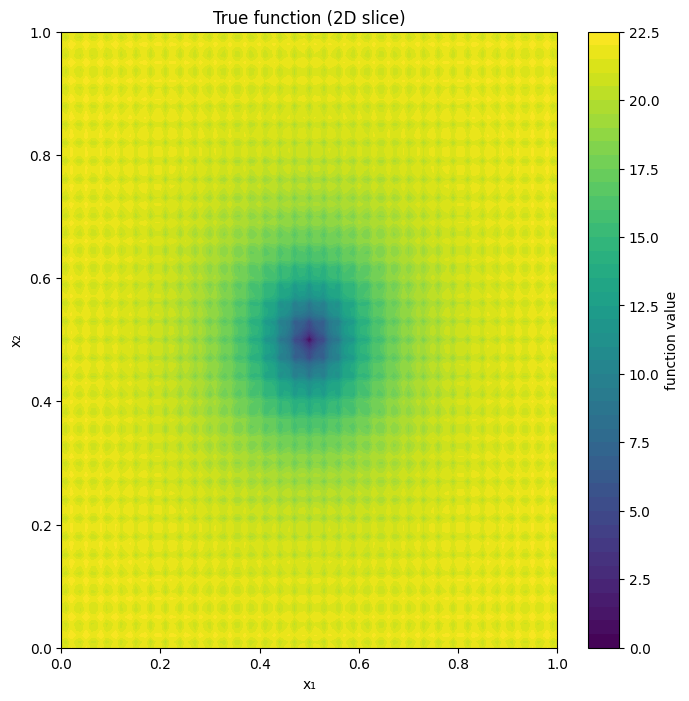

In [ ]:
f = Ackley(dim=2)
plot_true_function(f)

# Hartmann

In [ ]:
from Test_Function import Hartmann

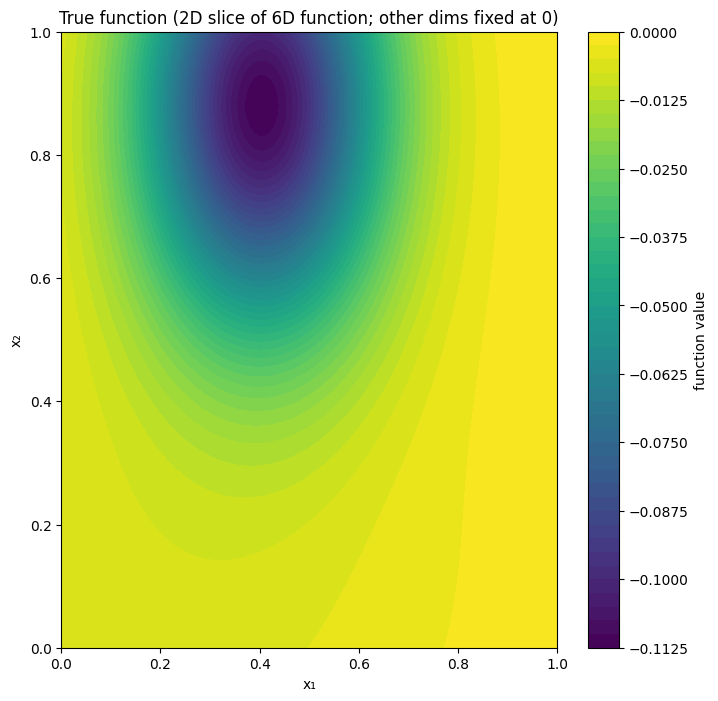

In [ ]:
f = Hartmann()
plot_true_function(f, fixed_dims_value=0)

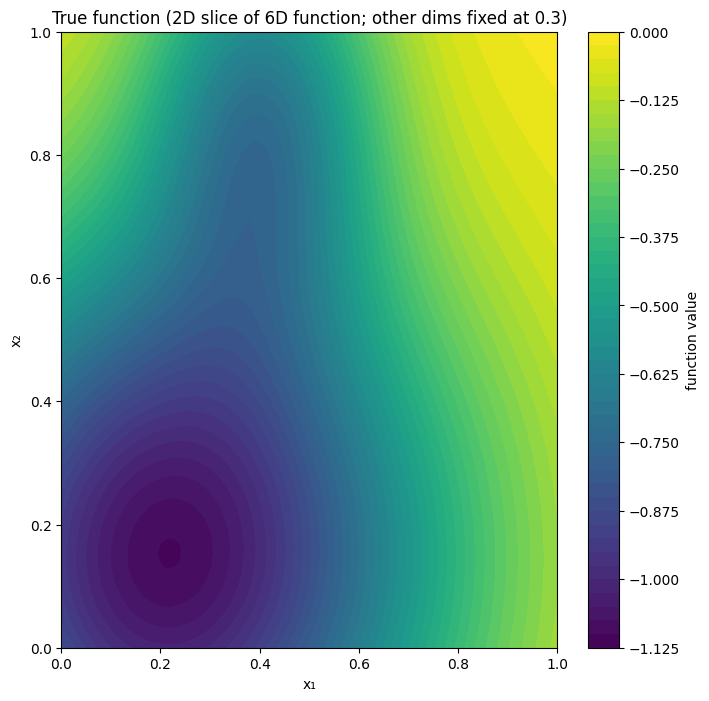

In [ ]:
f = Hartmann()
plot_true_function(f, fixed_dims_value=0.3)

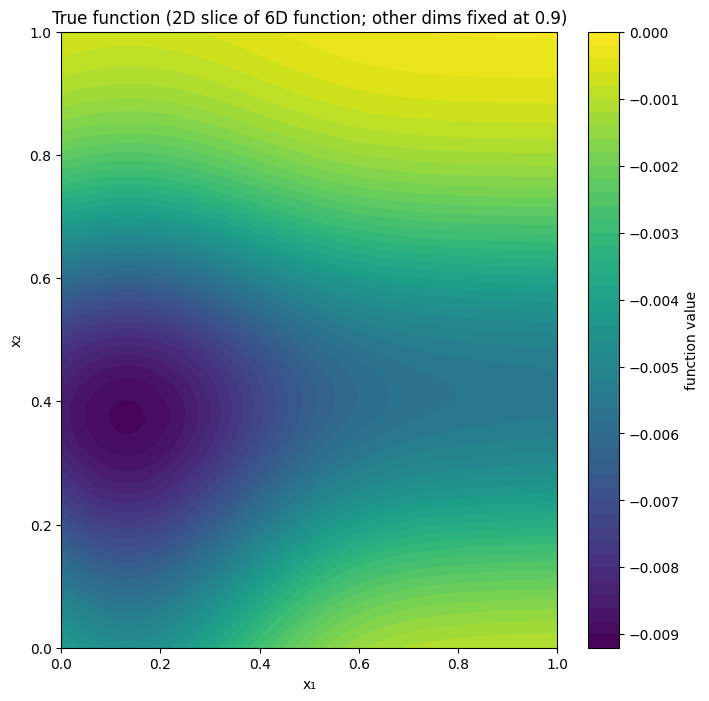

In [ ]:
f = Hartmann()
plot_true_function(f, fixed_dims_value=0.9)

# Modified_Branin

In [ ]:
from Test_Function import Modified_Branin

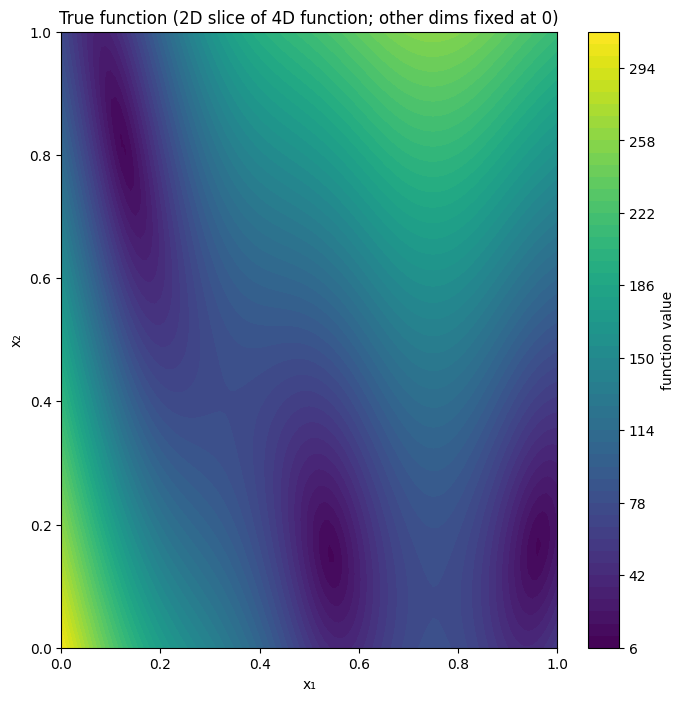

In [ ]:
f = Modified_Branin()
plot_true_function(f, fixed_dims_value=0)

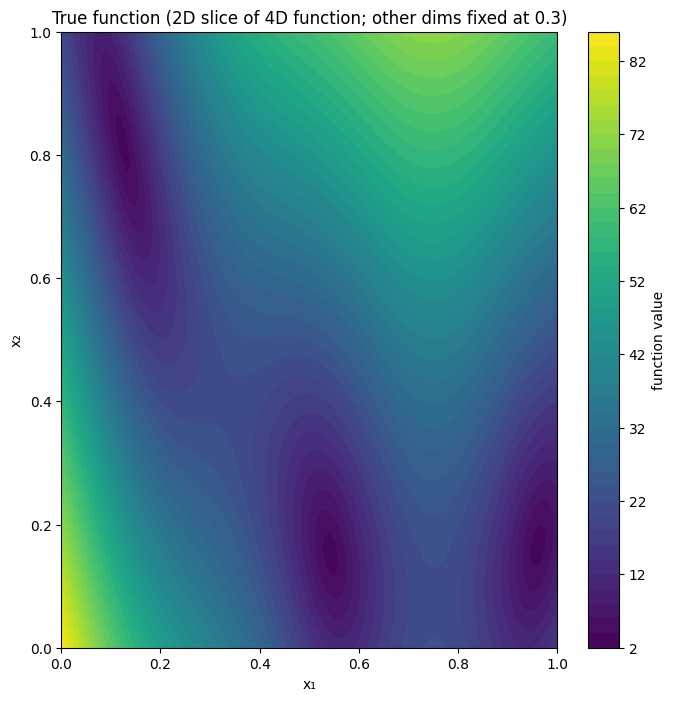

In [ ]:
f = Modified_Branin()
plot_true_function(f, fixed_dims_value=0.3)

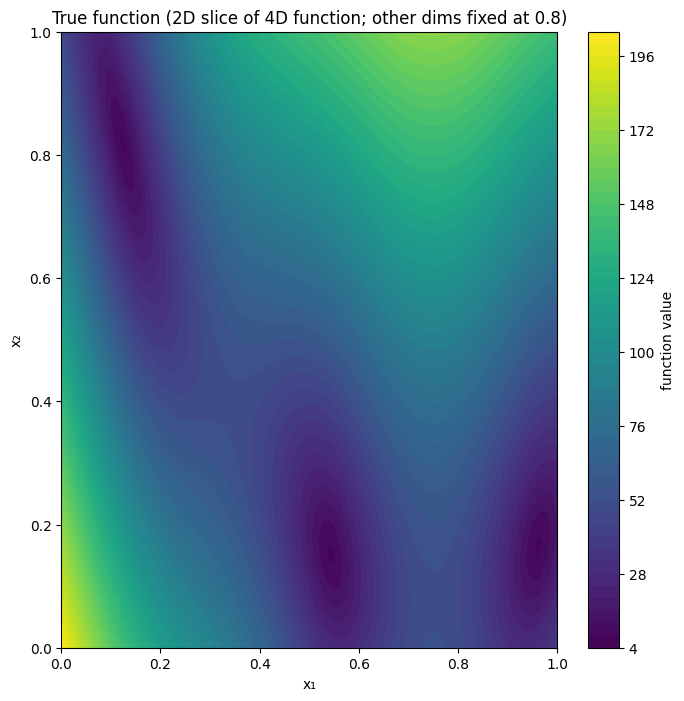

In [ ]:
f = Modified_Branin()
plot_true_function(f, fixed_dims_value=0.8)

# Hartmann_complicated

In [ ]:
from Test_Function import Hartmann_complicated

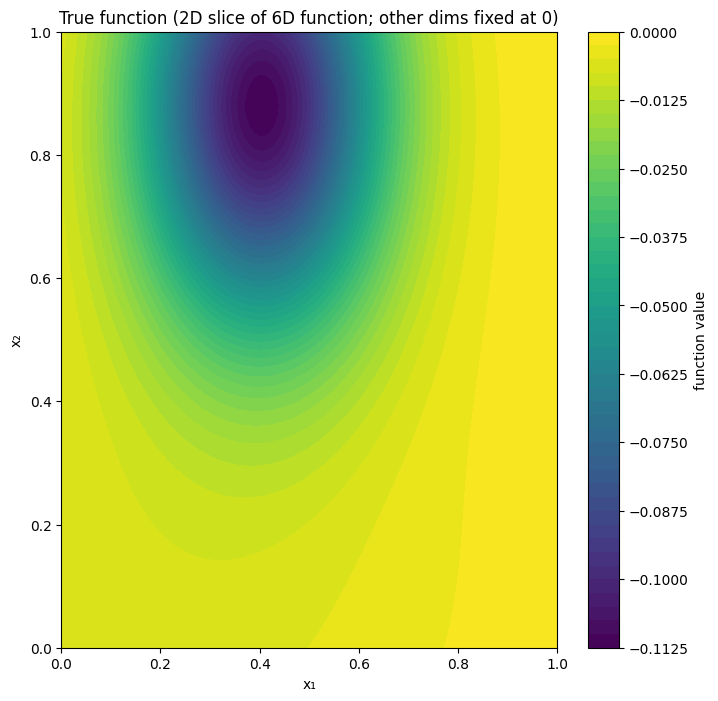

In [ ]:
f = Hartmann_complicated()
plot_true_function(f, fixed_dims_value=0)

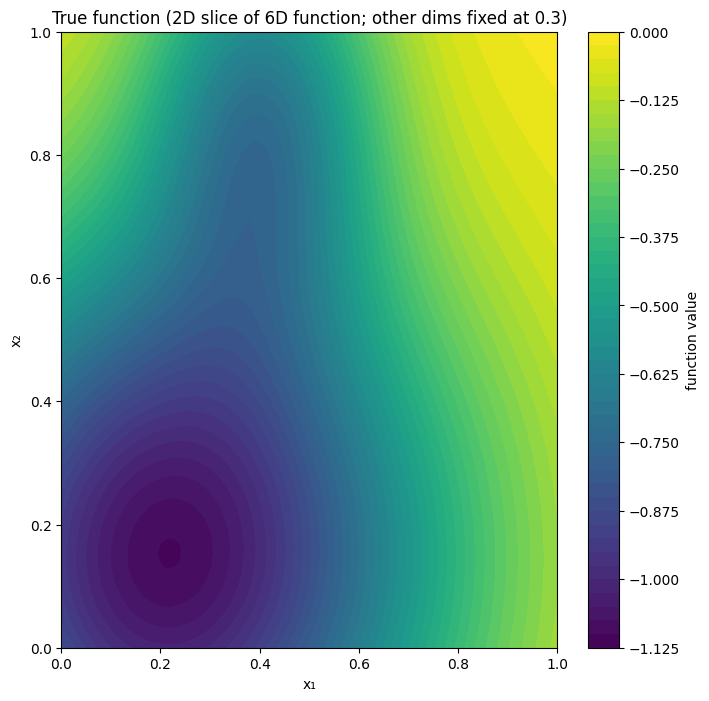

In [ ]:
f = Hartmann_complicated()
plot_true_function(f, fixed_dims_value=0.3)

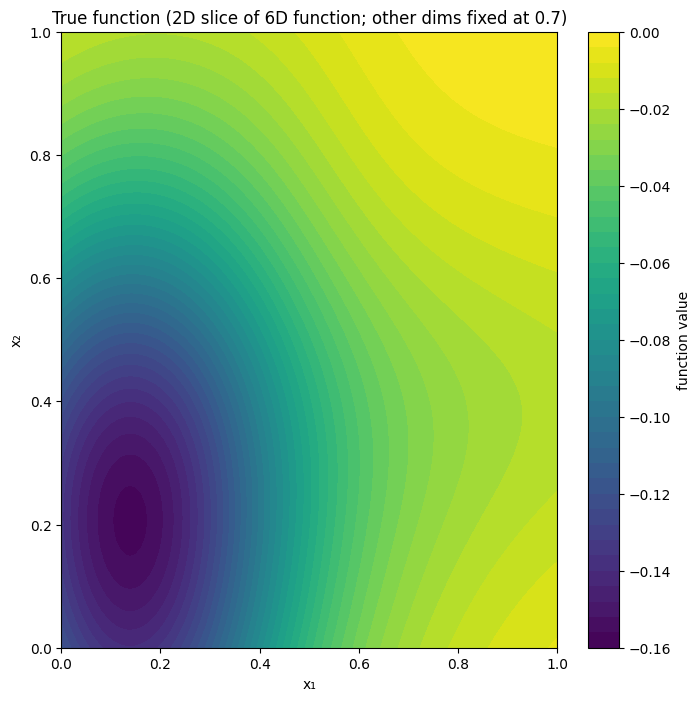

In [ ]:
f = Hartmann_complicated()
plot_true_function(f, fixed_dims_value=0.7)

# Continuous_Vendor

In [ ]:
from Test_Function import Continuous_Vendor

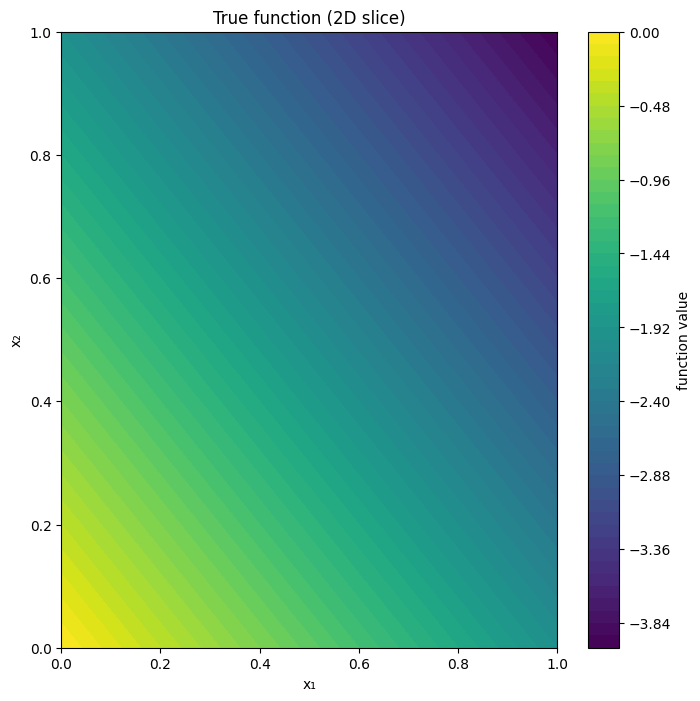

In [ ]:
f = Continuous_Vendor()
plot_true_function(f, fixed_dims_value=0)

# SixHumpCamel

In [ ]:
from Test_Function import SixHumpCamel

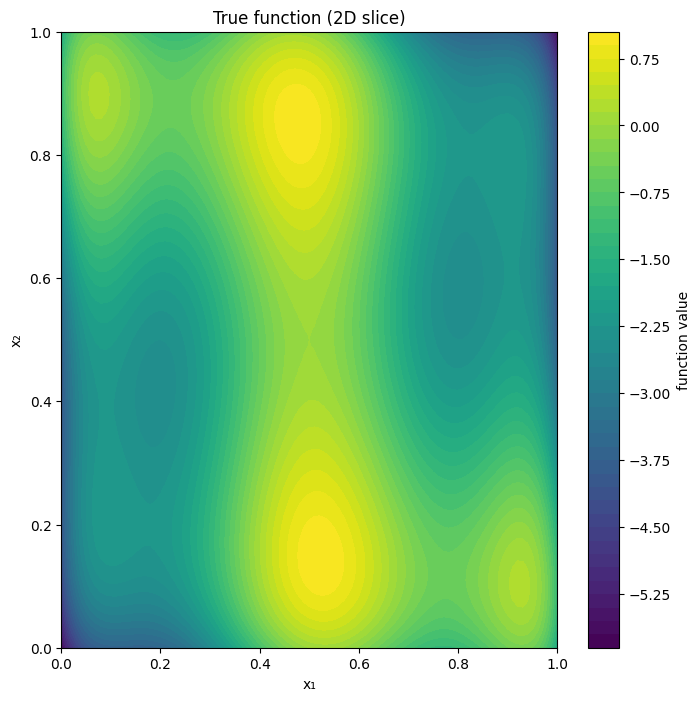

In [ ]:
f = SixHumpCamel()
plot_true_function(f, fixed_dims_value=0)

# ThreeHumpCamel

In [ ]:
from Test_Function import ThreeHumpCamel

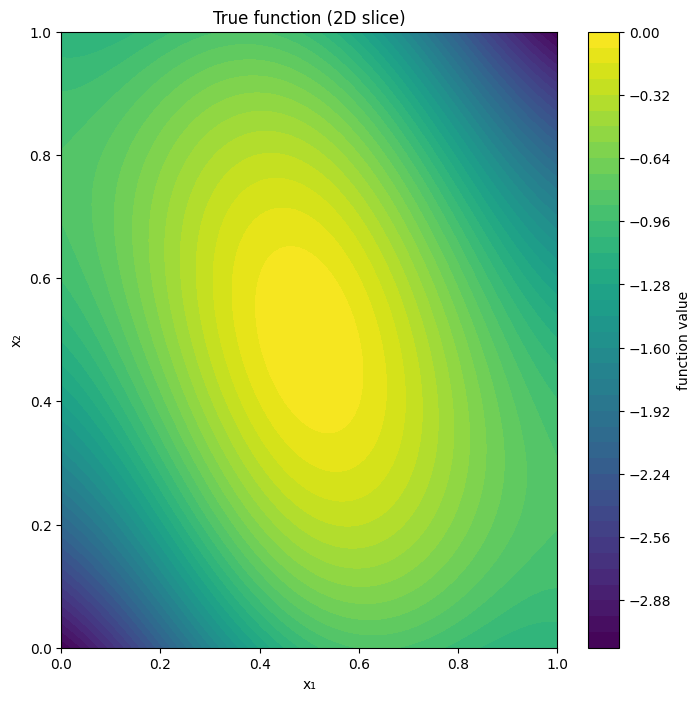

In [ ]:
f = ThreeHumpCamel()
plot_true_function(f, fixed_dims_value=0)

# Styblinski–Tang function

In [4]:
from Test_Function import StyblinskiTang

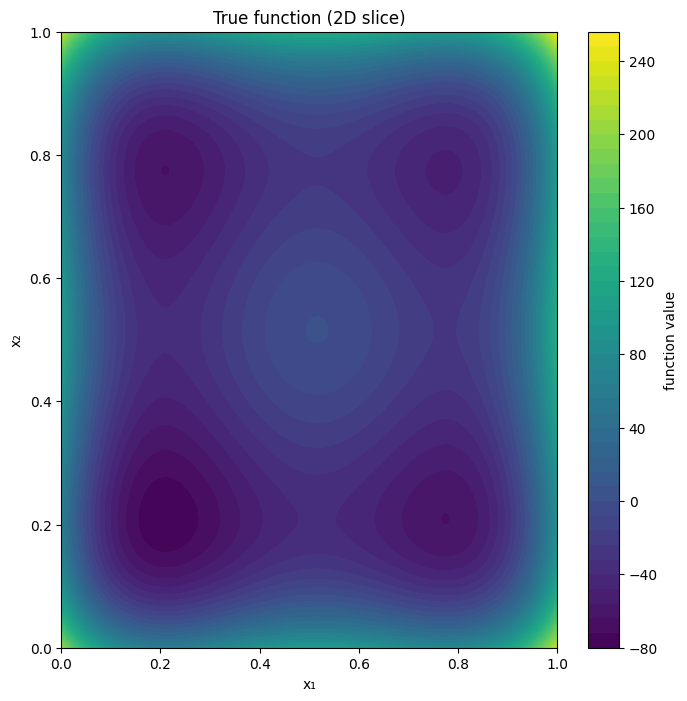

In [5]:
f = StyblinskiTang()
plot_true_function(f, fixed_dims_value=0)